# NB04b: LEPR/ArcPL external validation
Apply cleaned ML opx-liq model to ArcPL subset of LEPR for hydrous external validation.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
from config import (
    ROOT, DATA_RAW, DATA_EXTERNAL, DATA_PROC, DATA_SPLITS, DATA_NATURAL,
    MODELS, FIGURES, RESULTS, LOGS,
    EXPETDB, LEPR_XLSX, LIN2023_NATURAL,
    FE3_FET_RATIO, KD_FEMG_MIN, KD_FEMG_MAX, WO_MAX_MOL_PCT,
    P_CEILING_KBAR, CATION_SUM_MIN, CATION_SUM_MAX,
    OXIDE_TOTAL_MIN, OXIDE_TOTAL_MAX,
    SEED_SPLIT, SEED_MODEL, SEED_NOISE_AUG, SEED_KMEANS,
    OPX_RAW_OXIDES, OPX_FULL_OXIDES, LIQ_OXIDES,
)
import warnings
warnings.filterwarnings('ignore')

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
# Canonical features and prediction helpers from src/ (one source of truth).
from src.features import (
    build_feature_matrix,
    make_raw_features,
    make_alr_features,
    make_pwlr_features,
    augment_dataframe,
)
from src.models import predict_median, predict_iqr


In [3]:
# Cleaning steps mirroring NB01: cation recalc, oxide total, pigeonite, KD, features
OXIDE_MASSES = {
    'SiO2': 60.084, 'TiO2': 79.865, 'Al2O3': 101.961, 'Cr2O3': 151.989,
    'FeO': 71.844, 'FeO_total': 71.844, 'MnO': 70.937, 'MgO': 40.304,
    'CaO': 56.077, 'Na2O': 61.979, 'K2O': 94.196, 'P2O5': 141.943,
}
CATION_PER_OXIDE = {
    'SiO2': 1, 'TiO2': 1, 'Al2O3': 2, 'Cr2O3': 2, 'FeO': 1, 'FeO_total': 1,
    'MnO': 1, 'MgO': 1, 'CaO': 1, 'Na2O': 2, 'K2O': 2, 'P2O5': 2,
}
OXY_PER_OXIDE = {
    'SiO2': 2, 'TiO2': 2, 'Al2O3': 3, 'Cr2O3': 3, 'FeO': 1, 'FeO_total': 1,
    'MnO': 1, 'MgO': 1, 'CaO': 1, 'Na2O': 1, 'K2O': 1, 'P2O5': 5,
}

def cation_recalc_6oxy(df, oxides):
    out = df.copy()
    cat_factors = {}
    for ox in oxides:
        if ox not in df.columns: continue
        cat_factors[ox] = (df[ox] / OXIDE_MASSES[ox]) * CATION_PER_OXIDE[ox]
    moles_oxy = pd.DataFrame()
    for ox in oxides:
        if ox not in df.columns: continue
        moles_oxy[ox] = (df[ox] / OXIDE_MASSES[ox]) * OXY_PER_OXIDE[ox]
    moles_oxy = moles_oxy.fillna(0)
    sum_oxy = moles_oxy.sum(axis=1)
    factor = 6.0 / sum_oxy.replace(0, np.nan)
    for ox in oxides:
        if ox not in df.columns: continue
        out[f'{ox}_cat'] = cat_factors[ox] * factor
    cat_cols = [f'{ox}_cat' for ox in oxides if ox in df.columns]
    out['cation_sum'] = out[cat_cols].sum(axis=1)
    return out

def feature_engineer(df):
    out = df.copy()
    # Mg#
    out['Mg_num'] = (out['MgO'] / OXIDE_MASSES['MgO']) / (
        out['MgO'] / OXIDE_MASSES['MgO'] + out['FeO_total'] / OXIDE_MASSES['FeO_total'])
    # En/Fs/Wo on cation basis
    Mg = out.get('MgO_cat', 0)
    Fe = out.get('FeO_total_cat', 0)
    Ca = out.get('CaO_cat', 0)
    tot = Mg + Fe + Ca
    out['En_frac'] = Mg / tot
    out['Fs_frac'] = Fe / tot
    out['Wo_frac'] = Ca / tot
    out['Wo'] = out['Wo_frac'] * 100  # mol pct
    # Al_IV / Al_VI partition for opx (simplified): assume Si fills T-site to 2; Al_IV is shortfall
    Si_cat = out.get('SiO2_cat', 0)
    Al_cat = out.get('Al2O3_cat', 0)
    out['Al_IV'] = np.maximum(2.0 - Si_cat, 0)
    out['Al_VI'] = np.maximum(Al_cat - out['Al_IV'], 0)
    # MgTs (Mg-Tschermak): coupled Al_IV * Al_VI proxy
    out['MgTs'] = np.minimum(out['Al_IV'], out['Al_VI'])
    # Liquid Mg#
    if 'liq_MgO' in out.columns and 'liq_FeO' in out.columns:
        out['liq_Mg_num'] = (out['liq_MgO'] / OXIDE_MASSES['MgO']) / (
            out['liq_MgO'] / OXIDE_MASSES['MgO'] +
            out['liq_FeO'] / OXIDE_MASSES['FeO'])
    return out

In [4]:
# Load LEPR Opx-Liq sheet and filter to ArcPL subset
lepr = pd.read_excel(LEPR_XLSX, sheet_name='Opx-Liq')
print(f'LEPR Opx-Liq raw rows: {len(lepr)}')

arcpl = lepr[lepr['Citation_x'].str.contains('_notinLEPR', na=False)].copy()
print(f'ArcPL subset (_notinLEPR): {len(arcpl)} rows, {arcpl["Citation_x"].nunique()} studies')

LEPR Opx-Liq raw rows: 491
ArcPL subset (_notinLEPR): 324 rows, 23 studies


In [5]:
# Rename columns to ExPetDB-style schema
rename_map = {
    'Citation_x': 'Citation',
    'Experiment_x': 'Experiment',
    'P_kbar_x': 'P_kbar',
    'SiO2_Opx': 'SiO2', 'TiO2_Opx': 'TiO2', 'Al2O3_Opx': 'Al2O3',
    'FeOt_Opx': 'FeO_total', 'MnO_Opx': 'MnO', 'MgO_Opx': 'MgO',
    'CaO_Opx': 'CaO', 'Na2O_Opx': 'Na2O', 'K2O_Opx': 'K2O',
    'Cr2O3_Opx': 'Cr2O3', 'P2O5_Opx': 'P2O5',
    'SiO2_Liq': 'liq_SiO2', 'TiO2_Liq': 'liq_TiO2', 'Al2O3_Liq': 'liq_Al2O3',
    'FeOt_Liq': 'liq_FeO', 'MnO_Liq': 'liq_MnO', 'MgO_Liq': 'liq_MgO',
    'CaO_Liq': 'liq_CaO', 'Na2O_Liq': 'liq_Na2O', 'K2O_Liq': 'liq_K2O',
    'Cr2O3_Liq': 'liq_Cr2O3', 'H2O_Liq': 'H2O_Liq',
    'H2O_Liq_Method': 'H2O_Liq_Method', 'logfo2': 'logfo2',
}
arcpl = arcpl.rename(columns=rename_map)
arcpl['T_C'] = arcpl['T_K_x'] - 273.15
drop_y = [c for c in arcpl.columns if c.endswith('_y') or c == 'T_K_x']
arcpl = arcpl.drop(columns=drop_y, errors='ignore')

# Drop rows with negative H2O (data errors)
n_before = len(arcpl)
arcpl = arcpl[arcpl['H2O_Liq'] >= 0].copy()
print(f'Dropped {n_before - len(arcpl)} rows with negative H2O')

# is_vbd flag from H2O_Liq_Method
arcpl['is_vbd'] = arcpl['H2O_Liq_Method'].astype(str).str.contains(
    'VBD|vbd|mass_balance|diff', na=False, regex=True)
print(f'is_vbd count: {arcpl["is_vbd"].sum()}/{len(arcpl)}')

Dropped 2 rows with negative H2O
is_vbd count: 128/322


In [6]:
# Apply cleaning pipeline (cation recalc, oxide total, pigeonite, KD, features)
core_oxides = ['SiO2', 'Al2O3', 'FeO_total', 'MgO', 'CaO']
all_oxides = ['SiO2', 'TiO2', 'Al2O3', 'Cr2O3', 'FeO_total', 'MnO', 'MgO', 'CaO', 'Na2O', 'K2O', 'P2O5']

for ox in all_oxides:
    if ox in arcpl.columns:
        arcpl[ox] = pd.to_numeric(arcpl[ox], errors='coerce')

# Oxide total (use the oxide cols that exist)
present = [o for o in all_oxides if o in arcpl.columns]
arcpl['oxide_total'] = arcpl[present].sum(axis=1, min_count=5)
n_before = len(arcpl)
arcpl = arcpl[arcpl['oxide_total'].between(OXIDE_TOTAL_MIN, OXIDE_TOTAL_MAX)].copy()
print(f'Oxide total filter ({OXIDE_TOTAL_MIN}-{OXIDE_TOTAL_MAX}): {n_before} -> {len(arcpl)}')

# Cation recalculation
arcpl = cation_recalc_6oxy(arcpl, all_oxides)
n_before = len(arcpl)
arcpl = arcpl[arcpl['cation_sum'].between(CATION_SUM_MIN, CATION_SUM_MAX)].copy()
print(f'Cation sum filter ({CATION_SUM_MIN}-{CATION_SUM_MAX}): {n_before} -> {len(arcpl)}')

# Core oxide presence
n_before = len(arcpl)
arcpl = arcpl.dropna(subset=core_oxides).copy()
print(f'Core oxide presence: {n_before} -> {len(arcpl)}')

# Feature engineering
arcpl = feature_engineer(arcpl)

# Pigeonite filter
n_before = len(arcpl)
arcpl = arcpl[arcpl['Wo'] <= WO_MAX_MOL_PCT].copy()
print(f'Pigeonite filter (Wo <= {WO_MAX_MOL_PCT}): {n_before} -> {len(arcpl)}')

# Pressure ceiling
n_before = len(arcpl)
arcpl = arcpl[arcpl['P_kbar'] <= P_CEILING_KBAR].copy()
print(f'P ceiling filter: {n_before} -> {len(arcpl)}')

# KD equilibrium filter
mw_MgO, mw_FeO = 40.304, 71.844
arcpl['FeMg_opx'] = (arcpl['FeO_total']/mw_FeO) / (arcpl['MgO']/mw_MgO)
arcpl['FeMg_liq'] = (arcpl['liq_FeO']/mw_FeO) / (arcpl['liq_MgO']/mw_MgO)
arcpl['KD_FeMg'] = arcpl['FeMg_opx'] / arcpl['FeMg_liq']
n_before = len(arcpl)
arcpl = arcpl[arcpl['KD_FeMg'].between(KD_FEMG_MIN, KD_FEMG_MAX)].copy()
print(f'KD filter ({KD_FEMG_MIN}-{KD_FEMG_MAX}): {n_before} -> {len(arcpl)}')

Oxide total filter (95.0-102.0): 322 -> 318
Cation sum filter (3.95-4.05): 318 -> 317
Core oxide presence: 317 -> 317
Pigeonite filter (Wo <= 5.0): 317 -> 306
P ceiling filter: 306 -> 306
KD filter (0.23-0.35): 306 -> 204


In [7]:
# Drop overlap with ExPetDB (best-effort author+year match)
expetdb = pd.read_parquet(DATA_PROC / 'opx_clean_opx_liq.parquet')

def first_author_year(s):
    s = str(s)
    # Match leading lowercase/uppercase letters then 4-digit year
    m = re.match(r'^([A-Za-z]+).*?(\d{4})', s)
    if m:
        return (m.group(1).lower()[:6], m.group(2))
    return None

# ArcPL keys (from short codes like 'Hamada2008_notinLEPR')
arcpl['_key'] = arcpl['Citation'].apply(first_author_year)

# ExPetDB keys (from full text like 'Feig, S.T., Koepke, J. ... (2006) ...')
def expetdb_key(s):
    s = str(s)
    m = re.match(r'^([A-Za-z]+).*?\((\d{4})\)', s)
    if m:
        return (m.group(1).lower()[:6], m.group(2))
    return None

expetdb_keys = set()
for c in expetdb['Citation'].dropna().unique():
    k = expetdb_key(c)
    if k:
        expetdb_keys.add(k)
print(f'ExPetDB unique (author, year) keys: {len(expetdb_keys)}')

n_before = len(arcpl)
overlap_mask = arcpl['_key'].apply(lambda k: k in expetdb_keys)
print(f'Potential overlaps with ExPetDB: {overlap_mask.sum()}')
arcpl = arcpl[~overlap_mask].copy()
print(f'After dropping overlaps: {n_before} -> {len(arcpl)}')

print(f'\nFinal ArcPL: {len(arcpl)} samples from {arcpl["Citation"].nunique()} studies')
print(f'is_vbd: {arcpl["is_vbd"].sum()} / measured: {(~arcpl["is_vbd"]).sum()}')

ExPetDB unique (author, year) keys: 89
Potential overlaps with ExPetDB: 0
After dropping overlaps: 204 -> 204

Final ArcPL: 204 samples from 18 studies
is_vbd: 70 / measured: 134


In [8]:
# Load winning RF opx-liq model (matching NB04 fair-comparison choice)
import ast
from sklearn.ensemble import RandomForestRegressor

results_all = pd.read_csv(RESULTS / 'nb03_multi_seed_summary.csv')
rf_liq = results_all[(results_all.track=='opx_liq') & (results_all.model_name=='RF')]

rf_T = rf_liq[rf_liq.target=='T_C'].sort_values('rmse_test_mean').iloc[0]
rf_P = rf_liq[rf_liq.target=='P_kbar'].sort_values('rmse_test_mean').iloc[0]

fs_T, fs_P = rf_T['feature_set'], rf_P['feature_set']
print(f'Using RF opx-liq: T uses {fs_T}, P uses {fs_P}')


def get_or_train_rf(target, feat_set):
    fname = f'model_RF_{target}_opx_liq_{feat_set}.joblib'
    fpath = MODELS / fname
    if fpath.exists():
        return joblib.load(fpath)
    multi = pd.read_csv(RESULTS / 'nb03_multi_seed_results.csv')
    row = multi[(multi.track == 'opx_liq') &
                (multi.model_name == 'RF') &
                (multi.feature_set == feat_set) &
                (multi.target == target) &
                (multi.split_seed == 42)].iloc[0]
    try:
        params = ast.literal_eval(row['best_params'])
    except Exception:
        import json as _json
        params = _json.loads(row['best_params'])
    df_full = pd.read_parquet(DATA_PROC / 'opx_clean_opx_liq.parquet')
    tr_idx = np.load(DATA_SPLITS / 'train_indices_opx_liq.npy')
    df_tr = df_full.loc[tr_idx]
    X_tr, _ = build_feature_matrix(df_tr, feat_set, use_liq=True)
    y_tr = df_tr[target].values
    mdl = RandomForestRegressor(**params, random_state=SEED_MODEL, n_jobs=-1)
    mdl.fit(X_tr, y_tr)
    joblib.dump(mdl, fpath)
    print(f'Re-trained and cached {fname}')
    return mdl


model_T = get_or_train_rf('T_C', fs_T)
model_P = get_or_train_rf('P_kbar', fs_P)

X_T, _ = build_feature_matrix(arcpl, fs_T, use_liq=True)
X_P, _ = build_feature_matrix(arcpl, fs_P, use_liq=True)
arcpl['T_pred'] = model_T.predict(X_T)
arcpl['P_pred'] = model_P.predict(X_P)


Using RF opx-liq: T uses pwlr, P uses raw


In [9]:
# Metrics
def metrics(y_true, y_pred):
    yt = np.asarray(y_true, dtype=float); yp = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(yt) & np.isfinite(yp)
    if mask.sum() == 0:
        return {'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan, 'n': 0}
    return {
        'RMSE': float(np.sqrt(mean_squared_error(yt[mask], yp[mask]))),
        'MAE': float(mean_absolute_error(yt[mask], yp[mask])),
        'R2': float(r2_score(yt[mask], yp[mask])),
        'n': int(mask.sum()),
    }

print('ArcPL external validation (all samples):')
print('  T:', metrics(arcpl['T_C'].values, arcpl['T_pred'].values))
print('  P:', metrics(arcpl['P_kbar'].values, arcpl['P_pred'].values))

print('\nArcPL stratified by H2O method:')
for label, mask in [('measured (FTIR/SIMS/Raman/Sol)', ~arcpl['is_vbd']),
                    ('VBD/mass_balance', arcpl['is_vbd'])]:
    sub = arcpl[mask]
    print(f'  {label}: n={len(sub)}')
    if len(sub) > 5:
        print(f'    T:', metrics(sub['T_C'].values, sub['T_pred'].values))
        print(f'    P:', metrics(sub['P_kbar'].values, sub['P_pred'].values))

ArcPL external validation (all samples):
  T: {'RMSE': 65.6440682062727, 'MAE': 54.19999266910922, 'R2': 0.6301408154831598, 'n': 204}
  P: {'RMSE': 2.72098519520758, 'MAE': 2.2018745829732214, 'R2': 0.5689500569351711, 'n': 204}

ArcPL stratified by H2O method:
  measured (FTIR/SIMS/Raman/Sol): n=134
    T: {'RMSE': 62.116754814513925, 'MAE': 51.05155719070872, 'R2': 0.6881268328470377, 'n': 134}
    P: {'RMSE': 3.0991697571194057, 'MAE': 2.5797469196020586, 'R2': 0.532361234816711, 'n': 134}
  VBD/mass_balance: n=70
    T: {'RMSE': 71.9153756908228, 'MAE': 60.226997727761606, 'R2': 0.43828408779292793, 'n': 70}
    P: {'RMSE': 1.786124302411251, 'MAE': 1.4785189671408756, 'R2': 0.5943557007778107, 'n': 70}


In [10]:
# Save predictions and metrics
arcpl_out = arcpl.drop(columns=['_key'], errors='ignore').copy()
arcpl_out.to_csv(RESULTS / 'nb04b_arcpl_predictions.csv', index=False)

rows = []
for ds_label, mask in [
    ('ArcPL all', np.ones(len(arcpl), dtype=bool)),
    ('ArcPL measured H2O', ~arcpl['is_vbd'].values),
    ('ArcPL VBD H2O', arcpl['is_vbd'].values),
]:
    sub = arcpl[mask]
    if len(sub) == 0:
        continue
    for tgt, ycol, pcol in [('T', 'T_C', 'T_pred'), ('P', 'P_kbar', 'P_pred')]:
        m = metrics(sub[ycol].values, sub[pcol].values)
        rows.append({'dataset': ds_label, 'target': tgt, **m})
metrics_df = pd.DataFrame(rows)
metrics_df.to_csv(RESULTS / 'nb04b_arcpl_metrics.csv', index=False)
print('\nMetrics table:')
print(metrics_df.round(3).to_string(index=False))


Metrics table:
           dataset target   RMSE    MAE    R2   n
         ArcPL all      T 65.644 54.200 0.630 204
         ArcPL all      P  2.721  2.202 0.569 204
ArcPL measured H2O      T 62.117 51.052 0.688 134
ArcPL measured H2O      P  3.099  2.580 0.532 134
     ArcPL VBD H2O      T 71.915 60.227 0.438  70
     ArcPL VBD H2O      P  1.786  1.479 0.594  70


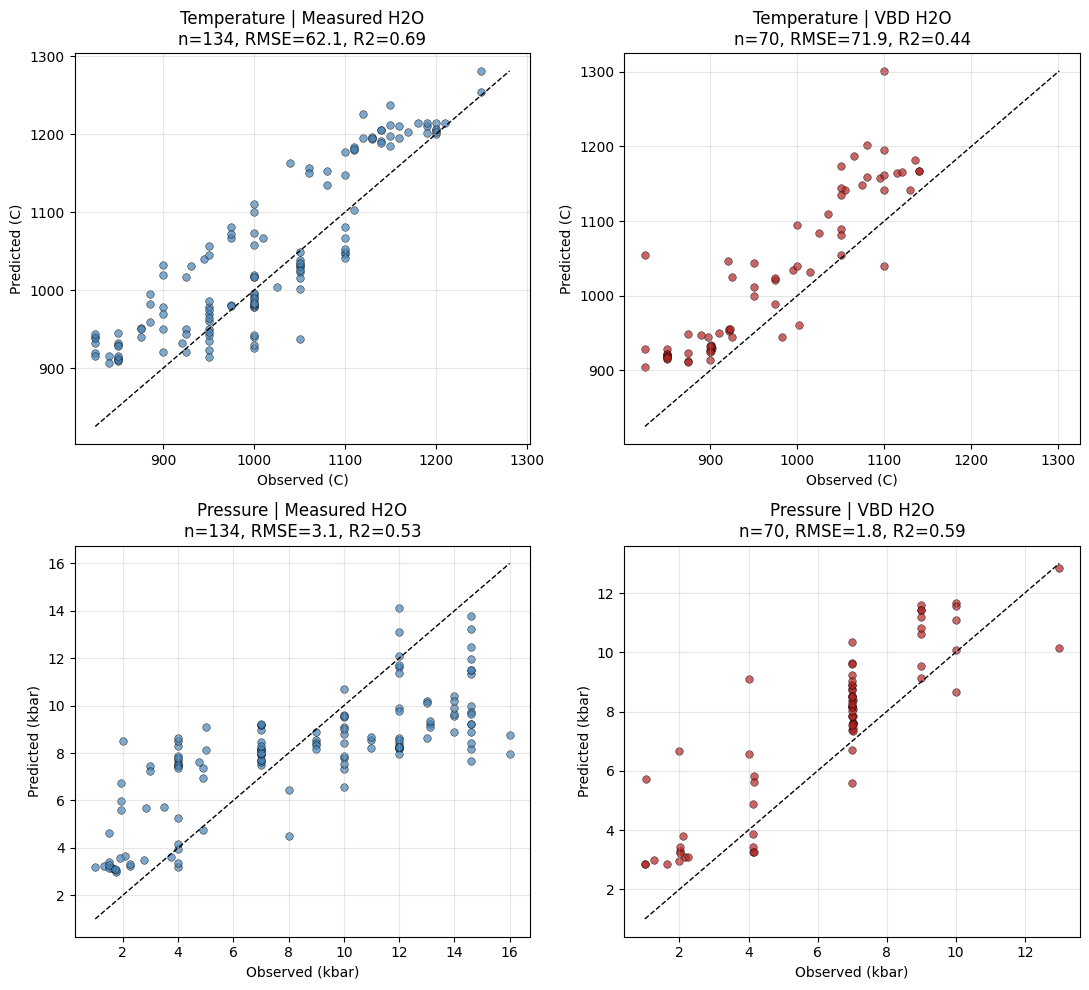

In [11]:
# Fig: pred vs obs scatter, T and P, separate panels for measured vs VBD
fig, axes = plt.subplots(2, 2, figsize=(11, 10))
for i, (target, ycol, pcol, unit) in enumerate([
    ('Temperature', 'T_C', 'T_pred', 'C'),
    ('Pressure', 'P_kbar', 'P_pred', 'kbar'),
]):
    for j, (label, mask, color) in enumerate([
        ('Measured H2O', ~arcpl['is_vbd'].values, 'steelblue'),
        ('VBD H2O', arcpl['is_vbd'].values, 'firebrick'),
    ]):
        ax = axes[i, j]
        sub = arcpl[mask]
        if len(sub) > 0:
            ax.scatter(sub[ycol], sub[pcol], s=30, c=color, alpha=0.7, edgecolor='k', lw=0.4)
            lo = min(sub[ycol].min(), sub[pcol].min())
            hi = max(sub[ycol].max(), sub[pcol].max())
            ax.plot([lo, hi], [lo, hi], 'k--', lw=1)
            m = metrics(sub[ycol].values, sub[pcol].values)
            ax.set_title(f'{target} | {label}\nn={m["n"]}, RMSE={m["RMSE"]:.1f}, R2={m["R2"]:.2f}')
        ax.set_xlabel(f'Observed ({unit})')
        ax.set_ylabel(f'Predicted ({unit})')
        ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES / 'fig_nb04b_arcpl_pred_vs_obs.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

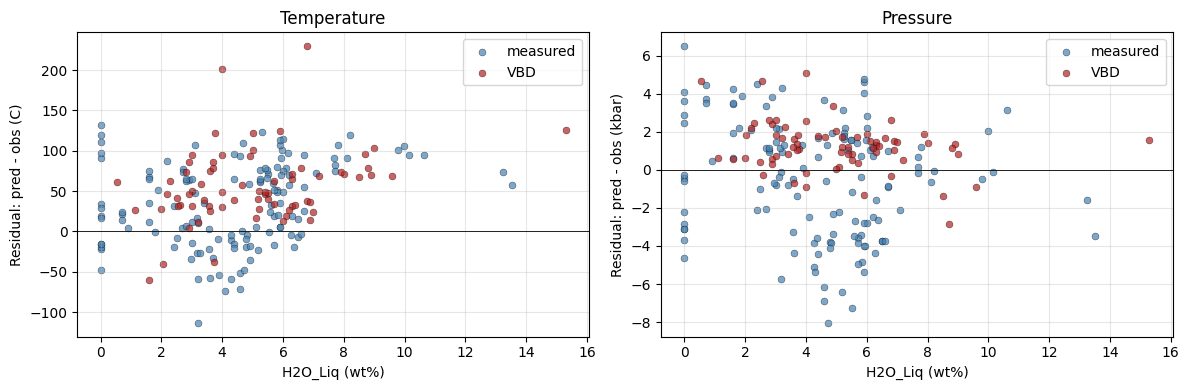

=== PHASE 4.5 COMPLETE ===


In [12]:
# Residuals vs H2O to check for systematic bias on hydrous samples
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (target, ycol, pcol, unit) in zip(axes, [
    ('Temperature', 'T_C', 'T_pred', 'C'),
    ('Pressure', 'P_kbar', 'P_pred', 'kbar'),
]):
    res = arcpl[pcol] - arcpl[ycol]
    measured = ~arcpl['is_vbd']
    ax.scatter(arcpl.loc[measured, 'H2O_Liq'], res[measured],
               s=25, c='steelblue', label='measured', alpha=0.7, edgecolor='k', lw=0.3)
    ax.scatter(arcpl.loc[~measured, 'H2O_Liq'], res[~measured],
               s=25, c='firebrick', label='VBD', alpha=0.7, edgecolor='k', lw=0.3)
    ax.axhline(0, color='k', lw=0.6)
    ax.set_xlabel('H2O_Liq (wt%)')
    ax.set_ylabel(f'Residual: pred - obs ({unit})')
    ax.set_title(target)
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES / 'fig_nb04b_arcpl_H2O_dependence.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print('=== PHASE 4.5 COMPLETE ===')

Formatting data and calculating Putirka estimates via Thermobar...

Putirka ArcPL T Failure Rate: 86.3%
Putirka ArcPL P Failure Rate: 86.3%

Fair Comparison (n=28 for T, n=28 for P)
Putirka T RMSE: 118.74 °C | ML T RMSE: 70.05 °C
Putirka P RMSE: 3.39 kbar | ML P RMSE: 2.81 kbar



Figure successfully saved to: C:\Users\NQTa\Documents\MLCourse\reports\figures\arcpl_putirka_benchmark.png


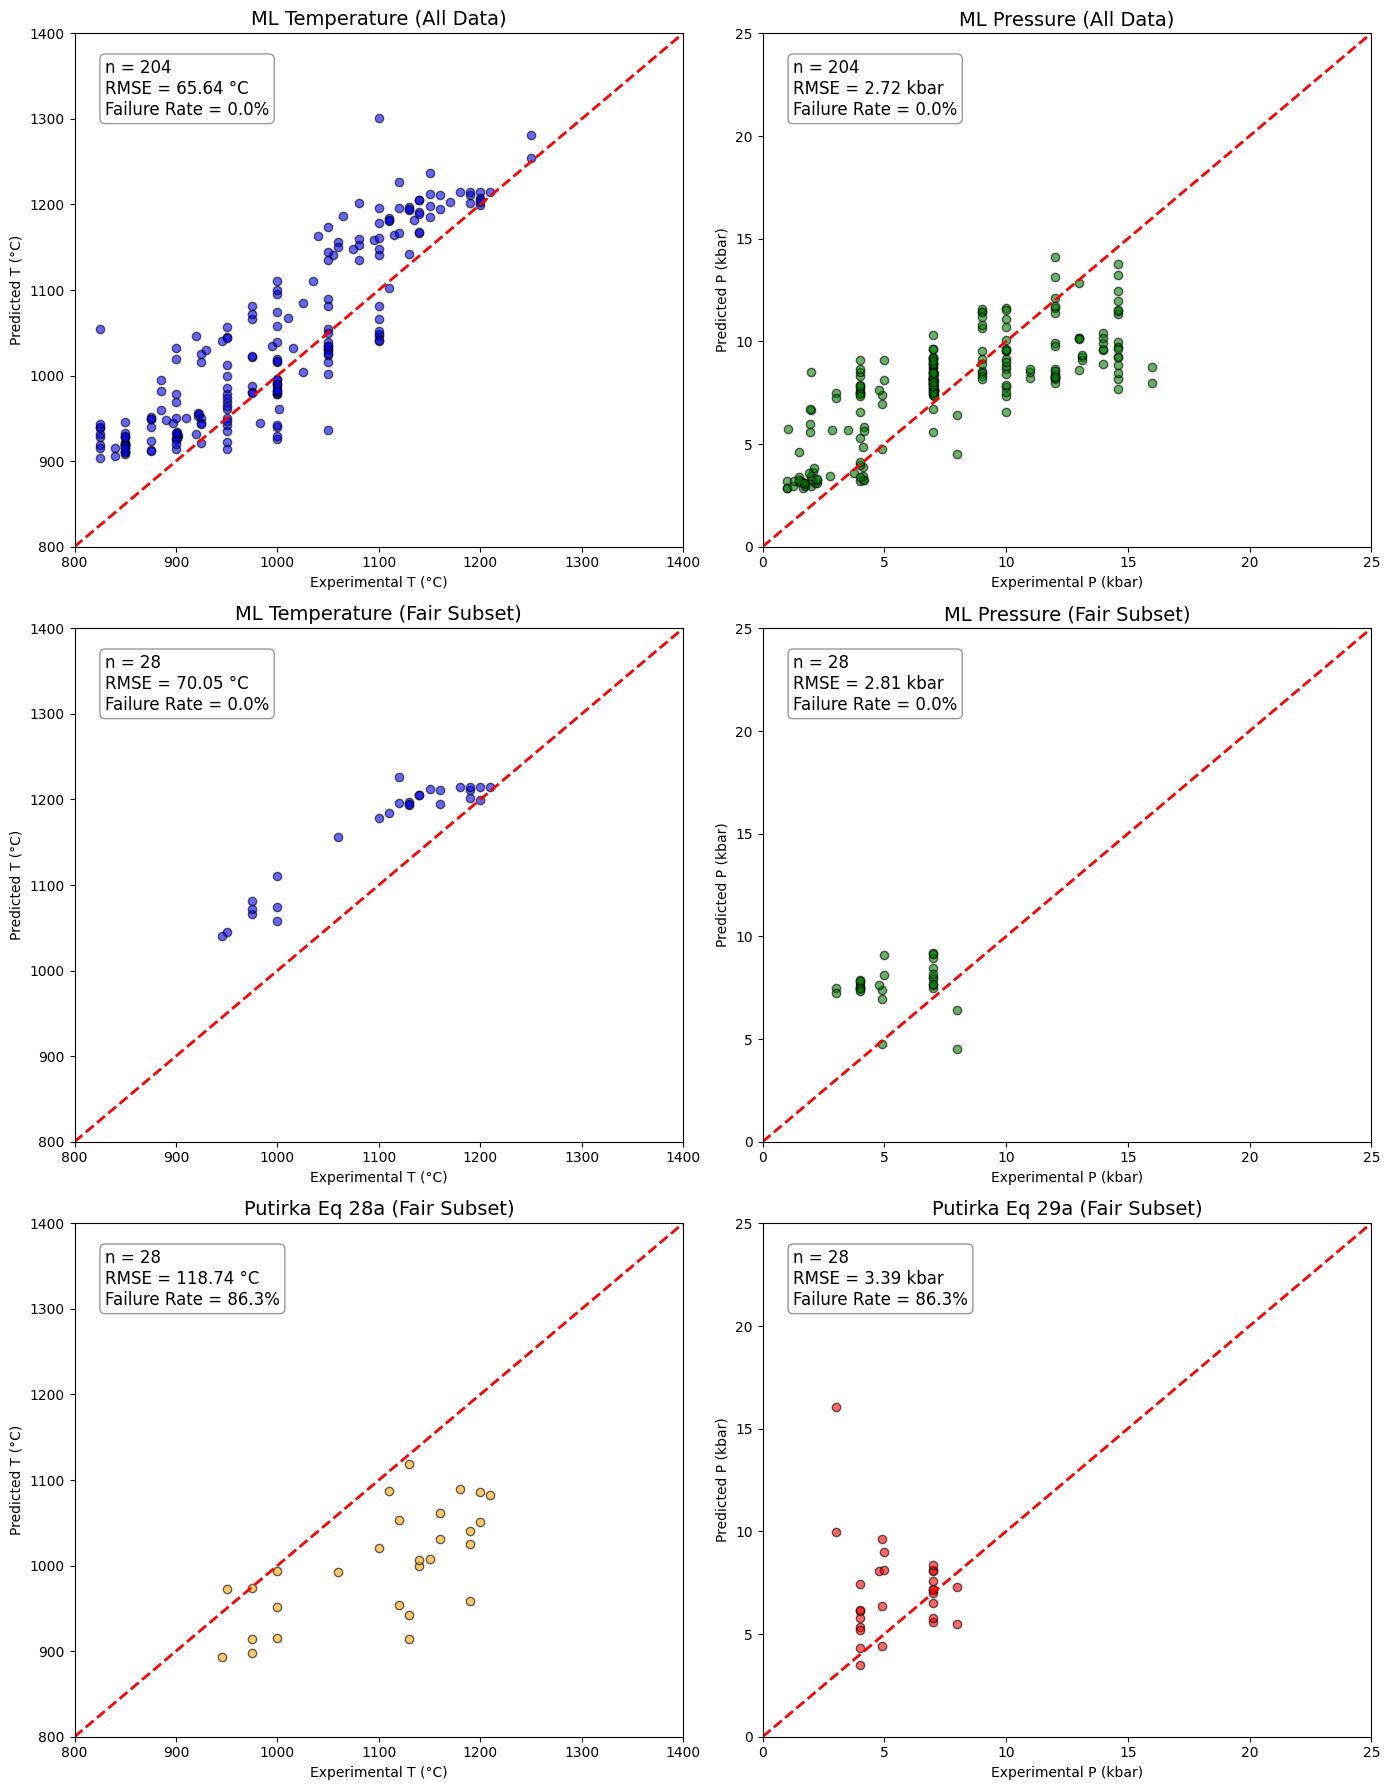

In [13]:
import sys
import os
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# 1. Guarantee Dependencies
def install_and_import(package, import_name):
    try:
        __import__(import_name)
    except ImportError:
        print(f"Installing missing dependency: {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])

install_and_import('pandas', 'pandas')
install_and_import('numpy', 'numpy')
install_and_import('matplotlib', 'matplotlib')
install_and_import('scikit-learn', 'sklearn')
install_and_import('Thermobar', 'Thermobar')

import Thermobar as pt

# 2. Path Resolution & Figure Directory Setup
project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

fig_dir = os.path.join(project_root, 'reports', 'figures')
os.makedirs(fig_dir, exist_ok=True)
save_path = os.path.join(fig_dir, 'arcpl_putirka_benchmark.png')

# 3. Safe Wrapper
def safe_thermobar(func, **kwargs):
    """Executes Thermobar functions and catches any convergence failures gracefully."""
    try:
        return func(**kwargs)
    except Exception as e:
        print(f"Thermobar calculation warning: {e}")
        idx = kwargs.get('opx_comps').index if kwargs.get('opx_comps') is not None else range(len(kwargs.get('T', [])))
        return pd.Series(np.nan, index=idx)

# 4. Processing and Plotting
if 'arcpl' not in locals() and 'arcpl' not in globals():
    print("Error: 'arcpl' is not defined. Run the preceding cells in nb04b to load the ArcPL data.")
else:
    print("Formatting data and calculating Putirka estimates via Thermobar...")
    
    # Format the dataframes precisely as Thermobar expects
    def g(col, default=0.0):
        if col in arcpl.columns:
            return arcpl[col].fillna(default).values.astype(float)
        return np.full(len(arcpl), default, dtype=float)

    opx_test = pd.DataFrame({
        'SiO2_Opx': g('SiO2'), 'TiO2_Opx': g('TiO2'), 'Al2O3_Opx': g('Al2O3'),
        'FeOt_Opx': g('FeO_total'), 'MgO_Opx': g('MgO'), 'CaO_Opx': g('CaO'),
        'MnO_Opx': g('MnO'), 'Cr2O3_Opx': g('Cr2O3'), 'Na2O_Opx': g('Na2O')
    })

    liq_test = pd.DataFrame({
        'SiO2_Liq': g('liq_SiO2'), 'TiO2_Liq': g('liq_TiO2'), 'Al2O3_Liq': g('liq_Al2O3'),
        'FeOt_Liq': g('liq_FeO'), 'MgO_Liq': g('liq_MgO'), 'CaO_Liq': g('liq_CaO'),
        'MnO_Liq': g('liq_MnO'), 'K2O_Liq': g('liq_K2O'), 'Na2O_Liq': g('liq_Na2O')
    })
    
    y_T_true = arcpl['T_C'].values
    y_P_true = arcpl['P_kbar'].values
    
    # Note: Use standard 0.15 for Fe3Fet_Liq if it doesn't exist, which aligns with standard pipeline protocols
    fe3_array = np.full(len(arcpl), 0.15)
    h2o_array = g('H2O_Liq')

    # Calculate Temperature (Putirka 28a)
    T_put_28a_K = safe_thermobar(
        pt.calculate_opx_liq_temp,
        equationT='T_Put2008_eq28a', opx_comps=opx_test, liq_comps=liq_test,
        P=y_P_true, Fe3Fet_Liq=fe3_array, H2O_Liq=h2o_array
    )
    arcpl['Putirka_T_pred'] = T_put_28a_K - 273.15
    arcpl.loc[(arcpl['Putirka_T_pred'] < 0) | (arcpl['Putirka_T_pred'] > 2000), 'Putirka_T_pred'] = np.nan

    # Calculate Pressure (Putirka 29a)
    P_put_29a = safe_thermobar(
        pt.calculate_opx_liq_press,
        equationP='P_Put2008_eq29a', opx_comps=opx_test, liq_comps=liq_test,
        T=y_T_true + 273.15, Fe3Fet_Liq=fe3_array, H2O_Liq=h2o_array
    )
    arcpl['Putirka_P_pred'] = P_put_29a
    arcpl.loc[(arcpl['Putirka_P_pred'] < -10) | (arcpl['Putirka_P_pred'] > 100), 'Putirka_P_pred'] = np.nan

    # 5. Filter for Successful Calculations ("Fair" Subset)
    df_putirka_fair_T = arcpl.dropna(subset=['Putirka_T_pred', 'T_C'])
    df_putirka_fair_P = arcpl.dropna(subset=['Putirka_P_pred', 'P_kbar'])

    t_fail_rate = (1 - len(df_putirka_fair_T) / len(arcpl)) * 100
    p_fail_rate = (1 - len(df_putirka_fair_P) / len(arcpl)) * 100

    print(f"\nPutirka ArcPL T Failure Rate: {t_fail_rate:.1f}%")
    print(f"Putirka ArcPL P Failure Rate: {p_fail_rate:.1f}%")

    putirka_t_rmse = np.sqrt(mean_squared_error(df_putirka_fair_T['T_C'], df_putirka_fair_T['Putirka_T_pred']))
    ml_t_rmse_fair = np.sqrt(mean_squared_error(df_putirka_fair_T['T_C'], df_putirka_fair_T['T_pred']))
    putirka_p_rmse = np.sqrt(mean_squared_error(df_putirka_fair_P['P_kbar'], df_putirka_fair_P['Putirka_P_pred']))
    ml_p_rmse_fair = np.sqrt(mean_squared_error(df_putirka_fair_P['P_kbar'], df_putirka_fair_P['P_pred']))

    print(f"\nFair Comparison (n={len(df_putirka_fair_T)} for T, n={len(df_putirka_fair_P)} for P)")
    print(f"Putirka T RMSE: {putirka_t_rmse:.2f} °C | ML T RMSE: {ml_t_rmse_fair:.2f} °C")
    print(f"Putirka P RMSE: {putirka_p_rmse:.2f} kbar | ML P RMSE: {ml_p_rmse_fair:.2f} kbar")

# 6. Plot generation with embedded metrics (Corrected Fair Comparisons)
    fig, axs = plt.subplots(3, 2, figsize=(14, 18))
    t_min, t_max = 800, 1400
    p_min, p_max = 0, 25

    # Calculate overall ML RMSE for the "All" plots
    ml_t_rmse_all = np.sqrt(mean_squared_error(arcpl['T_C'], arcpl['T_pred']))
    ml_p_rmse_all = np.sqrt(mean_squared_error(arcpl['P_kbar'], arcpl['P_pred']))

    # Box properties for text annotations
    props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')

    # --- ROW 1: ML Performance on ALL Data ---
    axs[0, 0].scatter(arcpl['T_C'], arcpl['T_pred'], alpha=0.6, color='blue', edgecolor='k')
    axs[0, 0].plot([t_min, t_max], [t_min, t_max], 'r--', lw=2)
    axs[0, 0].set_title("ML Temperature (All Data)", fontsize=14)
    axs[0, 0].set_xlim(t_min, t_max); axs[0, 0].set_ylim(t_min, t_max)
    axs[0, 0].set_xlabel("Experimental T (°C)"); axs[0, 0].set_ylabel("Predicted T (°C)")
    text_ml_t_all = f"n = {len(arcpl)}\nRMSE = {ml_t_rmse_all:.2f} °C\nFailure Rate = 0.0%"
    axs[0, 0].text(0.05, 0.95, text_ml_t_all, transform=axs[0, 0].transAxes, fontsize=12, verticalalignment='top', bbox=props)

    axs[0, 1].scatter(arcpl['P_kbar'], arcpl['P_pred'], alpha=0.6, color='green', edgecolor='k')
    axs[0, 1].plot([p_min, p_max], [p_min, p_max], 'r--', lw=2)
    axs[0, 1].set_title("ML Pressure (All Data)", fontsize=14)
    axs[0, 1].set_xlim(p_min, p_max); axs[0, 1].set_ylim(p_min, p_max)
    axs[0, 1].set_xlabel("Experimental P (kbar)"); axs[0, 1].set_ylabel("Predicted P (kbar)")
    text_ml_p_all = f"n = {len(arcpl)}\nRMSE = {ml_p_rmse_all:.2f} kbar\nFailure Rate = 0.0%"
    axs[0, 1].text(0.05, 0.95, text_ml_p_all, transform=axs[0, 1].transAxes, fontsize=12, verticalalignment='top', bbox=props)

    # --- ROW 2: ML Performance on the FAIR SUBSET ---
    axs[1, 0].scatter(df_putirka_fair_T['T_C'], df_putirka_fair_T['T_pred'], alpha=0.6, color='blue', edgecolor='k')
    axs[1, 0].plot([t_min, t_max], [t_min, t_max], 'r--', lw=2)
    axs[1, 0].set_title("ML Temperature (Fair Subset)", fontsize=14)
    axs[1, 0].set_xlim(t_min, t_max); axs[1, 0].set_ylim(t_min, t_max)
    axs[1, 0].set_xlabel("Experimental T (°C)"); axs[1, 0].set_ylabel("Predicted T (°C)")
    text_ml_t_fair = f"n = {len(df_putirka_fair_T)}\nRMSE = {ml_t_rmse_fair:.2f} °C\nFailure Rate = 0.0%"
    axs[1, 0].text(0.05, 0.95, text_ml_t_fair, transform=axs[1, 0].transAxes, fontsize=12, verticalalignment='top', bbox=props)

    axs[1, 1].scatter(df_putirka_fair_P['P_kbar'], df_putirka_fair_P['P_pred'], alpha=0.6, color='green', edgecolor='k')
    axs[1, 1].plot([p_min, p_max], [p_min, p_max], 'r--', lw=2)
    axs[1, 1].set_title("ML Pressure (Fair Subset)", fontsize=14)
    axs[1, 1].set_xlim(p_min, p_max); axs[1, 1].set_ylim(p_min, p_max)
    axs[1, 1].set_xlabel("Experimental P (kbar)"); axs[1, 1].set_ylabel("Predicted P (kbar)")
    text_ml_p_fair = f"n = {len(df_putirka_fair_P)}\nRMSE = {ml_p_rmse_fair:.2f} kbar\nFailure Rate = 0.0%"
    axs[1, 1].text(0.05, 0.95, text_ml_p_fair, transform=axs[1, 1].transAxes, fontsize=12, verticalalignment='top', bbox=props)

    # --- ROW 3: Putirka Performance on the FAIR SUBSET ---
    axs[2, 0].scatter(df_putirka_fair_T['T_C'], df_putirka_fair_T['Putirka_T_pred'], alpha=0.6, color='orange', edgecolor='k')
    axs[2, 0].plot([t_min, t_max], [t_min, t_max], 'r--', lw=2)
    axs[2, 0].set_title("Putirka Eq 28a (Fair Subset)", fontsize=14)
    axs[2, 0].set_xlim(t_min, t_max); axs[2, 0].set_ylim(t_min, t_max)
    axs[2, 0].set_xlabel("Experimental T (°C)"); axs[2, 0].set_ylabel("Predicted T (°C)")
    text_put_t = f"n = {len(df_putirka_fair_T)}\nRMSE = {putirka_t_rmse:.2f} °C\nFailure Rate = {t_fail_rate:.1f}%"
    axs[2, 0].text(0.05, 0.95, text_put_t, transform=axs[2, 0].transAxes, fontsize=12, verticalalignment='top', bbox=props)

    axs[2, 1].scatter(df_putirka_fair_P['P_kbar'], df_putirka_fair_P['Putirka_P_pred'], alpha=0.6, color='red', edgecolor='k')
    axs[2, 1].plot([p_min, p_max], [p_min, p_max], 'r--', lw=2)
    axs[2, 1].set_title("Putirka Eq 29a (Fair Subset)", fontsize=14)
    axs[2, 1].set_xlim(p_min, p_max); axs[2, 1].set_ylim(p_min, p_max)
    axs[2, 1].set_xlabel("Experimental P (kbar)"); axs[2, 1].set_ylabel("Predicted P (kbar)")
    text_put_p = f"n = {len(df_putirka_fair_P)}\nRMSE = {putirka_p_rmse:.2f} kbar\nFailure Rate = {p_fail_rate:.1f}%"
    axs[2, 1].text(0.05, 0.95, text_put_p, transform=axs[2, 1].transAxes, fontsize=12, verticalalignment='top', bbox=props)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"\nFigure successfully saved to: {save_path}")
    plt.show()